# Hotel Review Topic Modelling
## Pipeline: 

**Design decisions:**
- **Preprocessing**: City balanced stratified sample (~36,000 reviews, 30 hotels x 6 cities x 200 reviews each) using multilingual sentence embeddings (`paraphrase-multilingual-MiniLM-L12-v2`) and multilingual RoBERTa sentiment.
- **Topics**: 10 zero shot major topics.

**Pipeline overview:**
1. Stratified sampling (36k reviews, city balanced)
2. Text preprocessing and fragment splitting
3. Multilingual sentence embeddings
4. BERTopic with 10 zero shot major topics
5. Multilingual RoBERTa sentiment scoring
6. Hotel × topic aggregation
7. City benchmarking, gap analysis, radar charts
8. Single-hotel subtopic deep dive (3 subtopics per major topic)
9. Hotel vs area + city benchmark comparison at topic level
10. Peer hotel ranking + target vs all same-city hotels, composite percentile
11. Seasonal analysis + monthly/season heatmaps, city timeline benchmark

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import math
import re
import os
import scipy.cluster.hierarchy as sch
from scipy import stats

## 2. Stratified Hotel Sampling

In [3]:
# City Balanced Stratified Sampling
# 30 hotels x 6 cities x 200 reviews = ~36,000 reviews total.
# Saved on first run and reloaded automatically afterwards.
input_file  = "../Datasets/Hotel_Reviews.csv"
output_file = "../Datasets/Hotel_Reviews_StratSamp_Balanced.csv"

if os.path.exists(output_file):
    print(f"Stratified sample already exists — loading from {output_file}")
    df_sampled = pd.read_csv(output_file)
else:
    print("Building city-balanced stratified sample...")
    df = pd.read_csv(input_file)
    print(f"Full dataset : {len(df):,} reviews | {df['Hotel_Name'].nunique():,} hotels")

    def extract_city(address):
        if 'Netherlands' in address: return 'Amsterdam'
        elif 'United Kingdom' in address: return 'London'
        elif 'France' in address: return 'Paris'
        elif 'Spain' in address: return 'Barcelona'
        elif 'Italy' in address: return 'Milan'
        elif 'Austria' in address: return 'Vienna'
        else: return 'Other'

    df['City'] = df['Hotel_Address'].apply(extract_city)

    hotel_counts    = df.groupby('Hotel_Name').size()
    eligible_hotels = hotel_counts[hotel_counts >= 200].index
    df_eligible     = df[df['Hotel_Name'].isin(eligible_hotels)].copy()

    hotel_city_map_raw = df_eligible[['Hotel_Name', 'City']].drop_duplicates()
    print("Eligible Hotels per City:")
    print(hotel_city_map_raw['City'].value_counts())

    MAX_HOTELS_PER_CITY = 30
    balanced_hotels = hotel_city_map_raw.groupby('City').sample(
        n=MAX_HOTELS_PER_CITY, random_state=42
    )
    df_city_balanced = df_eligible.merge(balanced_hotels, on=['Hotel_Name', 'City'], how='inner')

    MAX_PER_HOTEL = 200
    df_sampled = (
        df_city_balanced
        .groupby(['Hotel_Name', 'City'])
        .sample(n=MAX_PER_HOTEL, random_state=42)
        .reset_index(drop=True)
    )
    df_sampled['ID'] = df_sampled.index
    df_sampled.to_csv(output_file, index=False)

    print(f"\n--- Final Balanced Dataset ---")
    print(f"Total Reviews : {len(df_sampled):,}")
    print(f"Hotels        : {df_sampled['Hotel_Name'].nunique()}")
    print(f"Cities        : {df_sampled['City'].nunique()}")

print(f"\nLoaded: {len(df_sampled):,} reviews | {df_sampled['Hotel_Name'].nunique()} hotels")

Stratified sample already exists — loading from ../Datasets/Hotel_Reviews_StratSamp_Balanced.csv

Loaded: 36,000 reviews | 180 hotels


## 3. Stop Words

To prevent the BERTopic model from creating uninformative clusters centred around widespread, dataset-specific terms (e.g. "hotel", "room", "stay"), the standard NLTK English stop words list was extended with custom domain-specific filler words. A random sample of 1,000 guest reviews was processed using a Large Language Model.

**Model Used:** ChatGPT Plus (GPT-5.4 Thinking Mode)

### The Prompt
> Act as an expert NLP data scientist. I am building a BERTopic model to analyse hotel guest reviews. I need a list of domain-specific stop words. These are frequent filler words that offer no value to a specific topic.
>
> **Constraints:**
> 1. **Include** generic nouns/verbs that appear constantly (e.g. "hotel", "room", "stay").
> 2. **DO NOT include** sentiment words (e.g. "good", "bad", "dirty").
> 3. **DO NOT include** feature-specific words (e.g. "breakfast", "bed", "shower", "staff").

### Output
```python
["hotel", "room", "rooms", "stay", "stayed", "booking", "booked", "check", "night", "day", "time", "area", "place", "city", "walk", "minutes", "people", "arrival", "asked", "told", "got", "pay", "work", "located", "near", "away", "floor", "building", "way", "morning"]
```

In [4]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Combine the stop words for all your target cities
all_languages = ['english', 'french', 'spanish', 'italian', 'german', 'dutch']
multi_stop_words = []

for lang in all_languages:
    multi_stop_words.extend(stopwords.words(lang))

domain_stop_words = [
    "hotel", "room", "rooms", "stay", "stayed", "booking", "booked", "check",
    "night", "day", "time", "area", "place", "city", "walk", "minutes",
    "people", "arrival", "asked", "told", "got", "pay", "work", "located",
    "near", "away", "floor", "building", "way", "morning"
]

# Add your custom domain stops (hotel, room, stay, etc.)
multi_stop_words.extend(domain_stop_words)

# Add city-specific and relevant terms appearing in topics but are not meaningful
domain_stop_words_2 = [
    # existing words causing issues
    "amsterdam", "barcelona", "london", "milan", "paris", "vienna",
    "netherlands", "spain", "france", "italy", "austria",
    "eiffel", "oxford", "gogh", "montmartre", "milano",
    "centre", "center", "street", "europe", "european"
]

multi_stop_words.extend(domain_stop_words_2)

# Remove duplicates
multi_stop_words = list(set(multi_stop_words))

print(f"Total Multilingual Stop Words: {len(multi_stop_words)}")

Total Multilingual Stop Words: 1238


## 4. Text Preprocessing

Reviews are split into short fragments at sentence or clause level so BERTopic can assign each fragment to a specific topic. The minimum 3 word filter removes any small split fragments.

In [5]:
def split_and_update_indices(text_list, index_list, split_list):
    """Split every string on each delimiter and expand index_list in parallel."""
    new_texts, new_indices = [], []
    for text, idx in zip(text_list, index_list):
        fragments = [text]
        for sep in split_list:
            expanded = []
            for frag in fragments:
                expanded.extend(frag.split(sep))
            fragments = expanded
        fragments = [f for f in fragments if f.strip()]
        new_texts.extend(fragments)
        new_indices.extend([idx] * len(fragments))
    return new_texts, new_indices

# 4. Zero-Shot Topic Generation for BERTopic Model

The following zero-shot topics were generated to guide the BERTopic model. To ensure the topics were highly relevant to this specific dataset, a random sample of 1,000 guest reviews was extracted and processed using a Large Language Model.

**Model Used:** ChatGPT Plus (GPT-5.4 Thinking Mode - Standard Effort)

### The Prompt
> Act as an expert hospitality data analyst. I have uploaded a CSV containing a random sample of 1,000 hotel guest reviews. I am building a BERTopic model and need to generate zero-shot topics.
>
> Please read the entire document carefully. Based strictly on the themes present in the text of these reviews, generate a list of 10 Major Topics (broad, high-level categories).
>
> Do not use booking metadata (like 'couple' or 'business trip') as topics. Focus exclusively on the actual sentiments and complaints the guests are writing about.

### The AI-Generated Output

#### 10 Major Topics
1. Staff Service
2. Room Comfort & Quality
3. Cleanliness
4. Location & Accessibility
5. Breakfast & Food
6. Bathroom & Shower Experience
7. Noise & Sleep Disturbance
8. Facilities & Amenities
9. Value for Money
10. Maintenance & Room Condition

In [ ]:
# 10 zero-shot major topics — the only topic list used in the main model
ZERO_SHOT_MAJOR_TOPICS = [
    "Staff Service",
    "Room Comfort & Quality",
    "Cleanliness",
    "Location & Accessibility",
    "Breakfast & Food",
    "Bathroom & Shower Experience",
    "Noise & Sleep Disturbance",
    "Facilities & Amenities",
    "Value for Money",
    "Maintenance & Room Condition"
]

def data_loader(
    csv_path     = "../Datasets/Hotel_Reviews_StratSamp_Balanced.csv",
    SplitterList = [". ", "! ", "? ", "; "],   # conservative to avoid over-splitting
    index        = "ID"
):
    """Load the sampled dataset and split reviews into short fragments."""
    RawText = pd.read_csv(csv_path)
    RawText['Negative_Review'] = RawText['Negative_Review'].apply(
        lambda x: math.nan if str(x).strip() == 'No Negative' else x
    )
    RawText['Positive_Review'] = RawText['Positive_Review'].apply(
        lambda x: math.nan if str(x).strip() == 'No Positive' else x
    )
    print(f"Loaded : {len(RawText):,} rows | {RawText['Hotel_Name'].nunique()} hotels")

    records = []
    for _, row in RawText.iterrows():
        for col in ["Negative_Review", "Positive_Review"]:
            val = row[col]
            if isinstance(val, float) and math.isnan(val):
                continue
            records.append({"text": str(val), "id": row[index], "hotel_name": row["Hotel_Name"]})

    docs       = [r["text"]       for r in records]
    doc_index  = [r["id"]         for r in records]
    doc_hotels = [r["hotel_name"] for r in records]
    print(f"Non-NaN entries before splitting: {len(docs):,}")

    if SplitterList:
        docs_orig = docs.copy()
        docs,  doc_index  = split_and_update_indices(docs_orig, doc_index,  SplitterList)
        _,     doc_hotels = split_and_update_indices(docs_orig, doc_hotels, SplitterList)
        print(f"After splitting               : {len(docs):,} fragments")

    MIN_WORDS = 3 # Minimum words per fragment to keep
    stop_set = set(multi_stop_words) 

    filtered = [
        (d.strip(), i, h) for d, i, h in zip(docs, doc_index, doc_hotels)
        if len(d.split()) >= MIN_WORDS and d.lower().strip() not in stop_set
    ]
    
    docs, doc_index, doc_hotels = map(list, zip(*filtered)) if filtered else ([], [], [])
    print(f"After filtering short fragments: {len(docs):,}")

    return docs, doc_index, doc_hotels

Name = "Hotel"
docs, docs_index, docs_hotels = data_loader()
print(f"\nReady: {len(docs):,} fragments | {len(set(docs_hotels))} hotels")

Loaded : 36,000 rows | 180 hotels
Non-NaN entries before splitting: 60,079
After splitting               : 59,983 fragments
After filtering short fragments: 53,507

Ready: 53,507 fragments | 180 hotels


## 5. Multilingual Sentence Embeddings

`paraphrase-multilingual-MiniLM-L12-v2` covers 50 or more languages and handles the mix of English, French, Spanish, Italian, German and Dutch reviews in this dataset.

In [7]:
from sentence_transformers import SentenceTransformer

os.makedirs("BERTModelRawOutputs", exist_ok=True)
EMBEDDING_PATH = f"BERTModelRawOutputs/{Name}_embeddings_multilingual.npy"

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

if os.path.exists(EMBEDDING_PATH):
    print(f"Loading saved embeddings from {EMBEDDING_PATH}")
    embeddings = np.load(EMBEDDING_PATH)
    assert len(embeddings) == len(docs), (
        "Embedding count mismatch, delete the .npy file and re-run this cell."
    )
else:
    print("Encoding documents (may take several minutes on CPU)...")
    embeddings = embedding_model.encode(
        docs, batch_size=64, show_progress_bar=True, convert_to_numpy=True
    )
    np.save(EMBEDDING_PATH, embeddings)
    print(f"Saved embeddings to {EMBEDDING_PATH}")

print(f"Embeddings shape: {embeddings.shape}")

c:\Users\HP ProBook\OneDrive - University of Bristol\Documents\MDM2\MDM2-ReviewsProj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2656.81it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading saved embeddings from BERTModelRawOutputs/Hotel_embeddings_multilingual.npy
Embeddings shape: (53507, 384)


## 6. BERTopic: 10 Zero Shot Major Topics

Zero shot mode seeds the model with the 10 predefined topic labels. Fragments are first matched against these seeds and any cluster that does not match is treated as an outlier. This removes the need for post hoc LLM semantic labelling.

In [8]:
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from bertopic.vectorizers import ClassTfidfTransformer

umap_model = UMAP(
    n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
hdbscan_model = HDBSCAN(
    min_cluster_size=30, min_samples=5, metric='euclidean',
    cluster_selection_method='eom', prediction_data=True
)
vectorizer_model  = CountVectorizer(stop_words=multi_stop_words, min_df=3, ngram_range=(1, 2))
ctfidf_model      = ClassTfidfTransformer(reduce_frequent_words=True)
representation_model = MaximalMarginalRelevance(diversity=0.8) # higher MMR diversity = more distinct topic representations

BERT_model = BERTopic(
    embedding_model      = embedding_model,
    umap_model           = umap_model,
    hdbscan_model        = hdbscan_model,
    vectorizer_model     = vectorizer_model,
    ctfidf_model         = ctfidf_model,
    representation_model = representation_model,
    # Zero shot: seed the model with 10 predefined topic labels
    zeroshot_topic_list    = ZERO_SHOT_MAJOR_TOPICS,
    zeroshot_min_similarity= 0.45,   # lower = more fragments assigned, raise if topics look mixed
    verbose                = True
)

topics, _ = BERT_model.fit_transform(docs, embeddings=embeddings)
print(f"\nTopics found (excl. outlier -1): {len(BERT_model.get_topic_info()) - 1}")

2026-04-04 16:50:40,571 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-04 16:51:37,753 - BERTopic - Dimensionality - Completed ✓
2026-04-04 16:51:37,770 - BERTopic - Zeroshot Step 1 - Finding documents that could be assigned to either one of the zero-shot topics
2026-04-04 16:51:38,920 - BERTopic - Zeroshot Step 1 - Completed ✓
2026-04-04 16:51:57,290 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-04 16:51:59,836 - BERTopic - Cluster - Completed ✓
2026-04-04 16:51:59,836 - BERTopic - Zeroshot Step 2 - Combining topics from zero-shot topic modeling with topics from clustering...
2026-04-04 16:51:59,919 - BERTopic - Zeroshot Step 2 - Completed ✓
2026-04-04 16:51:59,919 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-04 16:52:13,652 - BERTopic - Representation - Completed ✓



Topics found (excl. outlier -1): 155


## 7. Outlier Reduction and Topic Assignment

In [9]:
# Reassign outliers (-1) to their nearest topic using embedding similarity.
new_topics = BERT_model.reduce_outliers(
    docs, topics, strategy="embeddings", embeddings=embeddings
)
BERT_model.update_topics(docs, topics=new_topics)
topics = new_topics

print(f"Outliers remaining after reduction: {topics.count(-1):,}")
print(f"Topic distribution:")
print(pd.Series(topics).value_counts().sort_index())

2026-04-04 16:52:14,602 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outliers remaining after reduction: 0
Topic distribution:
0       3158
1      11554
2        790
3       2189
4       5672
       ...  
150      313
151      305
152      393
153      314
154      409
Name: count, Length: 155, dtype: int64


## 8. Apply Topic Labels and Save Document Info

In [10]:
# Map topic numbers to zero shot label strings
topic_info = BERT_model.get_topic_info()

# BERTopic zero shot mode names topics after the seed phrases automatically.
# Build the mapping from topic_id to semantic label.
topic_to_label = {}
for _, row in topic_info.iterrows():
    t = row['Topic']
    if t == -1:
        topic_to_label[t] = "Outlier"
    else:
        # The 'Name' column for zero shot topics is the seed phrase
        topic_to_label[t] = row['Name']

BERT_model.set_topic_labels(topic_to_label)

doc_inf = BERT_model.get_document_info(docs)
doc_inf["Person_id"]    = docs_index
doc_inf["Hotel_Name"]   = docs_hotels
doc_inf["Semantic_Label"] = doc_inf["Topic"].map(topic_to_label)

doc_inf.to_csv(f"BERTModelRawOutputs/{Name}_Document_Info.csv", index=False)
print(f"Saved {len(doc_inf):,} document records.")
print("\nTopic label distribution:")
print(doc_inf["Semantic_Label"].value_counts())

Saved 53,507 document records.

Topic label distribution:
Semantic_Label
Room Comfort & Quality             11554
Breakfast & Food                    5672
Maintenance & Room Condition        3413
Staff Service                       3158
Bathroom & Shower Experience        2353
                                   ...  
10_nothing_all_at_nothings            45
38_star_stars_rated_rating            45
39_iron_ironing_board_shirts          42
18_like_nothing_not_thing             41
13_perfect_just_every_satisfied       38
Name: count, Length: 155, dtype: int64


## 9. BERTopic Visualisations

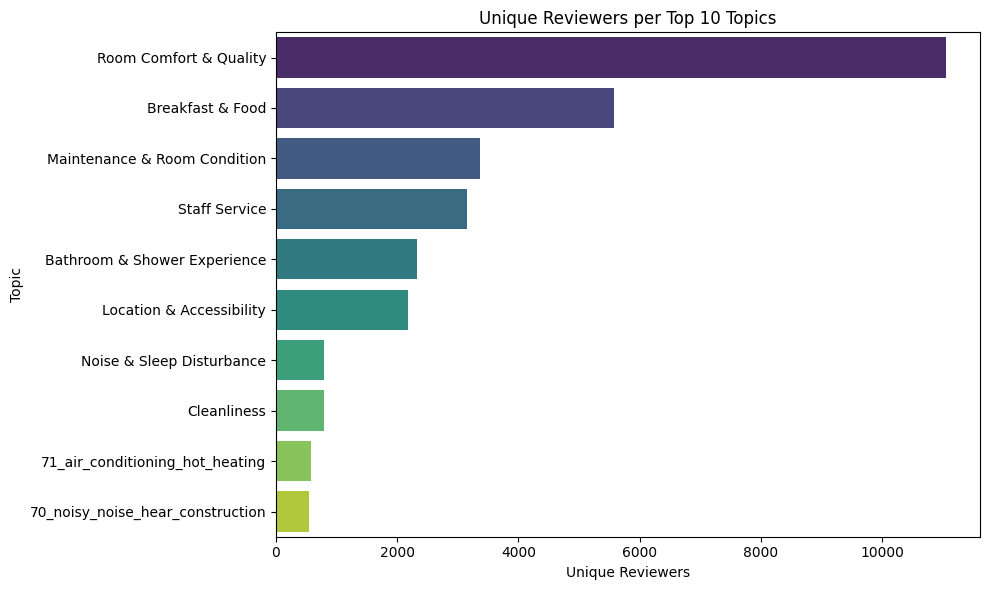

In [11]:
# Plot intertopic distance map

fig_intertopic = BERT_model.visualize_topics(custom_labels=True)
fig_intertopic.show()

# Plot top 10 topic word score barchart
fig_barchart = BERT_model.visualize_barchart(top_n_topics=10, n_words=10, custom_labels=True)
fig_barchart.show()


# Plot Unique Reviewers per Topic for top 10 topics
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate unique reviewers per topic, excluding outliers (-1)
top_inf = (
    doc_inf[doc_inf['Topic'] != -1]
    .groupby("Semantic_Label")
    .agg(Unique_Person_Count=("Person_id", "nunique"))
    .reset_index()
    .sort_values("Unique_Person_Count", ascending=False)
    .head(10) 
)

fig, ax = plt.subplots(figsize=(10, max(6, len(top_inf) * 0.4)))

sns.barplot(
    x="Unique_Person_Count", 
    y="Semantic_Label", 
    data=top_inf, 
    ax=ax, 
    palette="viridis"
)
ax.set(
    xlabel="Unique Reviewers", 
    ylabel="Topic", 
    title="Unique Reviewers per Top 10 Topics"
)

fig.tight_layout()
plt.show()


# Plot Hierarchical Dendrogram
fig_hierarchy = BERT_model.visualize_hierarchy(custom_labels=True)
fig_hierarchy.show()

## 10. Manually merge topics
After running the merge, re-run the get_topic_info() and doc_inf cells (step number 8 in the pipeline) to update the dataframes and visualisations with the new consolidated counts. Then run the cell above again to get updated visualisation charts.

In [12]:
# Uncomment if needed
'''
# Initialise empty lists
Topics_to_merge = []
merge_list = []

print("Manual Topic Merger:")
print("Enter the Topic IDs you want to combine (e.g., enter 9, then 10).")
print("Press 'm' to save that group and start a new one, or 'q' to finish and apply.")

while True:
    print(f"\nCurrent group being built: {merge_list}")
    topic_input = input("Enter Topic ID, 'm' to group, or 'q' to quit: ").strip().lower()
    
    if topic_input == 'q':
        break
    elif topic_input == 'm':
        if len(merge_list) > 1:
            Topics_to_merge.append(list(merge_list))
            print(f"Added group {merge_list} to merge queue.")
        else:
            print("Error: A merge group needs at least two IDs!")
        merge_list = []
    else:
        try:
            topic_id = int(topic_input)
            merge_list.append(topic_id)
        except ValueError:
            print("Invalid input. Please enter a number, 'm', or 'q'.")

# Apply the merge if we have groups
if len(Topics_to_merge) > 0:
    print(f"\nFinal list of merges to apply: {Topics_to_merge}")
    BERT_model.merge_topics(docs, topics_to_merge=Topics_to_merge)
    print("Success: Topics merged. You should now re-run your visualization cells.")
else:
    print("\nNo merges were performed.")
'''

'\n# Initialise empty lists\nTopics_to_merge = []\nmerge_list = []\n\nprint("Manual Topic Merger:")\nprint("Enter the Topic IDs you want to combine (e.g., enter 9, then 10).")\nprint("Press \'m\' to save that group and start a new one, or \'q\' to finish and apply.")\n\nwhile True:\n    print(f"\nCurrent group being built: {merge_list}")\n    topic_input = input("Enter Topic ID, \'m\' to group, or \'q\' to quit: ").strip().lower()\n\n    if topic_input == \'q\':\n        break\n    elif topic_input == \'m\':\n        if len(merge_list) > 1:\n            Topics_to_merge.append(list(merge_list))\n            print(f"Added group {merge_list} to merge queue.")\n        else:\n            print("Error: A merge group needs at least two IDs!")\n        merge_list = []\n    else:\n        try:\n            topic_id = int(topic_input)\n            merge_list.append(topic_id)\n        except ValueError:\n            print("Invalid input. Please enter a number, \'m\', or \'q\'.")\n\n# Apply the m

## 10. Multilingual RoBERTa Sentiment

`cardiffnlp/twitter-xlm-roberta-base-sentiment` is fine-tuned on 124M multilingual tweets
and covers negative / neutral / positive classes across the 6 languages in this dataset.

In [13]:
import os
import pandas as pd
from transformers import pipeline
from tqdm import tqdm

# File path for sentiment
SENTIMENT_PATH = f"BERTModelRawOutputs/{Name}_Sentiment_Scores.csv"

if os.path.exists(SENTIMENT_PATH):
    print(f"Loading saved sentiment scores from {SENTIMENT_PATH}...")
    saved_sentiments = pd.read_csv(SENTIMENT_PATH)
    
    doc_inf["Sentiment_Label"] = saved_sentiments["Sentiment_Label"]
    doc_inf["Sentiment_Score"] = saved_sentiments["Sentiment_Score"]
    print("Loaded instantly!")

else:
    # Initialise the sentiment analysis pipeline with the multilingual Twitter RoBERTa model
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model      = "cardiffnlp/twitter-xlm-roberta-base-sentiment",
        truncation = True,
        max_length = 64,  
        device     = -1 
    )

    label_map = {"negative": -1, "neutral": 0, "positive": 1}
    batch_size = 32
    all_results = []

    print(f"Running sentiment on {len(docs):,} fragments...")

    # Progress bar
    for i in tqdm(range(0, len(docs), batch_size), desc="Scoring"):
        batch_docs = docs[i : i + batch_size]
        batch_results = sentiment_pipeline(batch_docs)
        all_results.extend(batch_results)

    # Add results to doc_inf
    doc_inf["Sentiment_Label"] = [s['label'] for s in all_results]
    doc_inf["Sentiment_Score"] = [label_map.get(s['label'], 0) * s['score'] for s in all_results]

    # Save sentiment file so it doesn't have to be run again
    sentiment_df = doc_inf[["Sentiment_Label", "Sentiment_Score"]]
    sentiment_df.to_csv(SENTIMENT_PATH, index=False)
    print(f"Saved standalone sentiment scores to {SENTIMENT_PATH}")

# Save the full combined doc_inf with topics and sentiment for future analysis
doc_inf.to_csv(f"BERTModelRawOutputs/{Name}_Document_Info.csv", index=False)
doc_inf[["Document", "Semantic_Label", "Hotel_Name", "Sentiment_Label", "Sentiment_Score"]].head()

Loading saved sentiment scores from BERTModelRawOutputs/Hotel_Sentiment_Scores.csv...
Loaded instantly!


,Document,Semantic_Label,Hotel_Name,Sentiment_Label,Sentiment_Score
0,Just I dident like the breakfast regulation ab...,Breakfast & Food,AC Hotel Barcelona Forum a Marriott Lifestyle ...,negative,-0.892868
1,The hotel design view was nice I liked it if i...,50_barcelona_best_hotel_in,AC Hotel Barcelona Forum a Marriott Lifestyle ...,positive,0.885348
2,The breakfast was amazing And the bath was jus...,Breakfast & Food,AC Hotel Barcelona Forum a Marriott Lifestyle ...,positive,0.890813
3,Pool didnt get good sun and was freezing cold ...,71_air_conditioning_hot_heating,AC Hotel Barcelona Forum a Marriott Lifestyle ...,negative,-0.913072
4,Beds Service Cleanliness,Cleanliness,AC Hotel Barcelona Forum a Marriott Lifestyle ...,neutral,0.000000


## 11. Merge Reviewer Scores and Extract City

Each review fragment is linked back to the original numeric reviewer score and hotel address from the raw dataset. The city is extracted from the address string so hotels can later be grouped and compared within the same city.


In [14]:
cols_to_drop = [c for c in doc_inf.columns if any(
    c == x or c.startswith(x)
    for x in ['Reviewer_Score', 'Average_Score', 'Hotel_Address',
               'Hotel_Name_orig', 'City']
)]
doc_inf = doc_inf.drop(columns=cols_to_drop)

doc_inf['Person_id'] = doc_inf['Person_id'].astype(int)
df_sampled['ID']     = df_sampled['ID'].astype(int)

# Merge the reviewer score and hotel address back on to the fragment table using the Person_id / ID as the key
df_scores = (
    df_sampled[['ID', 'Reviewer_Score', 'Average_Score', 'Hotel_Address']]
    .copy()
    .rename(columns={'ID': 'Person_id'})
    .drop_duplicates(subset='Person_id')
)
doc_inf = doc_inf.merge(df_scores, on='Person_id', how='left')

KNOWN_CITIES = {'Amsterdam', 'Barcelona', 'London', 'Milan', 'Paris', 'Vienna'}

def extract_city(address):
    if not isinstance(address, str):
        return 'Unknown'
    for city in KNOWN_CITIES:
        if city.lower() in address.lower():
            return city
    return 'Unknown'

doc_inf['City'] = doc_inf['Hotel_Address'].apply(extract_city)

# Build a lookup table: hotel name → city
hotel_city_map = (
    doc_inf[['Hotel_Name', 'City']]
    .drop_duplicates()
    .set_index('Hotel_Name')['City']
    .to_dict()
)

doc_inf.to_csv(f'BERTModelRawOutputs/{Name}_Document_Info.csv', index=False)
print('City distribution:')
print(doc_inf['City'].value_counts())


City distribution:
City
London       9143
Amsterdam    9126
Barcelona    8961
Vienna       8791
Paris        8755
Milan        8731
Name: count, dtype: int64


## 12. Hotel and Topic Sentiment Aggregation

Mean sentiment is calculated for every hotel and topic pair. Pairs with fewer than three fragments are removed because the average would be unreliable with so little data.


In [15]:
hotel_topic_sentiment = (
    doc_inf[doc_inf['Topic'] != -1]
    .groupby(['Hotel_Name', 'Semantic_Label'])
    .agg(
        Mean_Sentiment = ('Sentiment_Score', 'mean'),
        Fragment_Count = ('Sentiment_Score', 'count')
    )
    .reset_index()
)

# Keep only the 10 zero shot topics and pairs with at least 3 fragments.
hotel_topic_sentiment = hotel_topic_sentiment[
    hotel_topic_sentiment['Semantic_Label'].isin(ZERO_SHOT_MAJOR_TOPICS)
]
hotel_topic_sentiment = hotel_topic_sentiment[
    hotel_topic_sentiment['Fragment_Count'] >= 3
].copy()

hotel_topic_sentiment.to_csv(
    f"BERTModelRawOutputs/{Name}_Hotel_Topic_Sentiment.csv", index=False
)
print(f"Hotel and topic pairs (3 or more fragments): {len(hotel_topic_sentiment):,}")
hotel_topic_sentiment.head(20)


Hotel and topic pairs (3 or more fragments): 1,391


,Hotel_Name,Semantic_Label,Mean_Sentiment,Fragment_Count
74,AC Hotel Barcelona Forum a Marriott Lifestyle ...,Bathroom & Shower Experience,0.526523,6
75,AC Hotel Barcelona Forum a Marriott Lifestyle ...,Breakfast & Food,0.411747,30
76,AC Hotel Barcelona Forum a Marriott Lifestyle ...,Cleanliness,0.297888,6
78,AC Hotel Barcelona Forum a Marriott Lifestyle ...,Location & Accessibility,0.190137,7
79,AC Hotel Barcelona Forum a Marriott Lifestyle ...,Maintenance & Room Condition,-0.595695,18
80,AC Hotel Barcelona Forum a Marriott Lifestyle ...,Noise & Sleep Disturbance,-0.448882,5
81,AC Hotel Barcelona Forum a Marriott Lifestyle ...,Room Comfort & Quality,0.458484,44
82,AC Hotel Barcelona Forum a Marriott Lifestyle ...,Staff Service,0.244732,14
149,Acad mie H tel Saint Germain,Bathroom & Shower Experience,0.106847,17
150,Acad mie H tel Saint Germain,Breakfast & Food,-0.334029,17


## 13. Visualisations: Donut, Heatmap and Sentiment Bar Charts by Topic

Three plot types are produced here:
- A donut chart shows how review fragments are distributed across the ten topics.
- A heatmap shows mean sentiment for every hotel and topic pair. **(Might not need)**
- Individual bar charts rank all hotels by sentiment for each of the ten topics. **(Might not need)**

In [16]:
import plotly.graph_objects as go
import plotly.express as px
import os

os.makedirs("BERTModelRawOutputs/Plots", exist_ok=True)

# 1. Donut Chart: distribution of review fragments across the 10 topics
topic_counts = (
    doc_inf[
        (doc_inf['Topic'] != -1) &
        (doc_inf['Semantic_Label'].isin(ZERO_SHOT_MAJOR_TOPICS))
    ]
    .groupby('Semantic_Label').size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
)

fig_donut = go.Figure(go.Pie(
    labels=topic_counts['Semantic_Label'],
    values=topic_counts['Count'],
    hole=0.4,  # Creates the donut hole in the middle
    textinfo='label+percent',
    textposition='outside', 
    marker=dict(colors=px.colors.sequential.Blues[::-1])
))

fig_donut.update_layout(
    title=dict(text='<b>Topic Distribution Across All Reviews</b>', x=0.5),
    showlegend=False, 
    margin=dict(t=80, b=40, l=40, r=40)
)

fig_donut.write_html('BERTModelRawOutputs/Plots/Donut_Topic_Distribution.html')
fig_donut.show()

# 2. Heatmap: mean sentiment per hotel and topic (10 topics only)
filtered_sentiment = hotel_topic_sentiment[
    hotel_topic_sentiment['Semantic_Label'].isin(ZERO_SHOT_MAJOR_TOPICS)
]

pivot = filtered_sentiment.pivot(
    index='Hotel_Name', columns='Semantic_Label', values='Mean_Sentiment'
)

fig_heatmap = px.imshow(
    pivot,
    color_continuous_scale='RdBu', color_continuous_midpoint=0,
    aspect='auto', title='<b>Mean Sentiment by Hotel and Topic</b>',
    labels=dict(color='Sentiment')
)
fig_heatmap.update_layout(
    xaxis_title='Topic', yaxis_title='Hotel',
    margin=dict(t=70, l=260, r=20, b=140),
    height=int((40 * len(pivot.index) + 120) / 2)
)
fig_heatmap.update_xaxes(tickangle=35)
fig_heatmap.write_html('BERTModelRawOutputs/Plots/Heatmap_Hotel_Topic_Sentiment.html')
fig_heatmap.show()

# 3. Sentiment bar charts, one chart per zero shot topic
for topic_label in ZERO_SHOT_MAJOR_TOPICS:
    # Skip if no hotel data exists for this topic
    if topic_label not in hotel_topic_sentiment['Semantic_Label'].values:
        continue

    subset = (hotel_topic_sentiment[hotel_topic_sentiment['Semantic_Label'] == topic_label]
              .sort_values('Mean_Sentiment'))

    fig_t = px.bar(
        subset, x='Mean_Sentiment', y='Hotel_Name', orientation='h',
        color='Mean_Sentiment', color_continuous_scale='RdBu',
        color_continuous_midpoint=0,
        title=f'<b>{topic_label}</b>: Sentiment Ranking by Hotel',
        labels={'Mean_Sentiment': 'Mean Sentiment', 'Hotel_Name': 'Hotel'}
    )
    fig_t.update_layout(margin=dict(t=60, l=220, r=20, b=40),
                         height=int((40 * len(subset) + 120) / 2))

    safe = topic_label.replace(' ', '_').replace('/', '_').replace('&', 'and')
    fig_t.write_html(f"BERTModelRawOutputs/Plots/Topic_{safe}_Hotels.html")
    fig_t.show()

print("All ten topic bar charts saved.")


All ten topic bar charts saved.


## 14. Validation: Sentiment vs Reviewer Score

This checks whether the RoBERTa sentiment score correlates with the numeric reviewer score already in the dataset. A strong correlation confirms that the sentiment model is capturing something meaningful rather than random noise.


In [17]:
review_level = (
    doc_inf[doc_inf['Topic'] != -1]
    .groupby('Person_id')
    .agg(
        Mean_Sentiment = ('Sentiment_Score', 'mean'),
        Reviewer_Score = ('Reviewer_Score',  'first'),
        Average_Score  = ('Average_Score',   'first'),
        Hotel_Name     = ('Hotel_Name',      'first'),
        City           = ('City',            'first')
    )
    .dropna(subset=['Reviewer_Score', 'Mean_Sentiment'])
    .reset_index()
)

r_pearson,  p_pearson  = stats.pearsonr( review_level['Reviewer_Score'], review_level['Mean_Sentiment'])
r_spearman, p_spearman = stats.spearmanr(review_level['Reviewer_Score'], review_level['Mean_Sentiment'])
print(f'Pearson  r = {r_pearson:.3f}  (p = {p_pearson:.2e})')
print(f'Spearman r = {r_spearman:.3f}  (p = {p_spearman:.2e})')

fig_corr = px.scatter(
    review_level, x='Reviewer_Score', y='Mean_Sentiment', color='City',
    opacity=0.5, trendline='ols', trendline_scope='overall',
    title=f'<b>RoBERTa Sentiment vs Reviewer Score</b><br>Pearson r = {r_pearson:.3f}',
    labels={'Reviewer_Score': 'Reviewer Score (1 to 10)', 'Mean_Sentiment': 'Mean Sentiment (-1 to +1)'}
)
fig_corr.write_html('BERTModelRawOutputs/Plots/Validation_Sentiment_vs_ReviewerScore.html')
fig_corr.show()


Pearson  r = 0.571  (p = 0.00e+00)
Spearman r = 0.575  (p = 0.00e+00)


## 15. Topic Correlations with Reviewer Score

Pearson correlation is calculated between each topic's mean sentiment and the numeric reviewer score. This shows which topics have the strongest relationship with the overall guest rating.


In [18]:
topic_correlations = []
for label in ZERO_SHOT_MAJOR_TOPICS:  # Only run over the 10 zero shot topics
    subset = (
        doc_inf[doc_inf['Semantic_Label'] == label]
        .groupby('Person_id')
        .agg(Topic_Sentiment=('Sentiment_Score','mean'), Reviewer_Score=('Reviewer_Score','first'))
        .dropna()
    )
    if len(subset) < 20:
        continue
    r, p = stats.pearsonr(subset['Reviewer_Score'], subset['Topic_Sentiment'])
    topic_correlations.append({'Topic': label, 'Pearson_r': round(r, 3),
                                'p_value': round(p, 4), 'n_reviews': len(subset), 'Significant': p < 0.05})

corr_df = pd.DataFrame(topic_correlations).sort_values('Pearson_r', ascending=False).reset_index(drop=True)
print(corr_df.to_string(index=False))
corr_df.to_csv(f'BERTModelRawOutputs/{Name}_Topic_ReviewerScore_Correlations.csv', index=False)

fig_tc = px.bar(corr_df.sort_values('Pearson_r'), x='Pearson_r', y='Topic', orientation='h',
                color='Pearson_r', color_continuous_scale='RdBu', color_continuous_midpoint=0,
                title='<b>Which Topics Most Drive the Overall Reviewer Score?</b>',
                labels={'Pearson_r': 'Pearson r with Reviewer Score', 'Topic': ''})
fig_tc.update_layout(margin=dict(t=70, l=240, r=20, b=60), showlegend=False)
fig_tc.write_html('BERTModelRawOutputs/Plots/TopicCorrelations_with_ReviewerScore.html')
fig_tc.show()


                       Topic  Pearson_r  p_value  n_reviews  Significant
               Staff Service      0.424      0.0       3145         True
      Room Comfort & Quality      0.372      0.0      11059         True
Maintenance & Room Condition      0.370      0.0       3368         True
      Facilities & Amenities      0.366      0.0        232         True
                 Cleanliness      0.350      0.0        789         True
             Value for Money      0.308      0.0        282         True
Bathroom & Shower Experience      0.243      0.0       2322         True
   Noise & Sleep Disturbance      0.209      0.0        796         True
    Location & Accessibility      0.127      0.0       2185         True
            Breakfast & Food      0.126      0.0       5572         True


## 16. City Benchmark

Mean sentiment is aggregated at city level for each topic across all hotels. This gives a benchmark that individual hotels can be compared against within their own city.


In [19]:
doc_inf['City'] = doc_inf['Hotel_Name'].map(hotel_city_map)

city_topic_benchmark = (
    doc_inf[(doc_inf['Topic'] != -1) & (doc_inf['City'] != 'Unknown')]
    .groupby(['City', 'Semantic_Label'])
    .agg(
        City_Mean_Sentiment = ('Sentiment_Score', 'mean'),
        City_Fragment_Count = ('Sentiment_Score', 'count'),
        City_Hotel_Count    = ('Hotel_Name',      'nunique')
    )
    .reset_index()
)

# Keep only the 10 zero shot topics
city_topic_benchmark = city_topic_benchmark[
    city_topic_benchmark['Semantic_Label'].isin(ZERO_SHOT_MAJOR_TOPICS)
]
city_topic_benchmark.to_csv(f'BERTModelRawOutputs/{Name}_City_Topic_Benchmark.csv', index=False)

pivot_city = city_topic_benchmark.pivot(
    index='City', columns='Semantic_Label', values='City_Mean_Sentiment'
)
fig_city = px.imshow(pivot_city, color_continuous_scale='RdBu', color_continuous_midpoint=0,
                     aspect='auto', title='<b>City Level Benchmark: Mean Topic Sentiment by City</b>',
                     labels=dict(color='Sentiment'))
fig_city.update_layout(xaxis_title='Topic', yaxis_title='City',
                        margin=dict(t=70, l=100, r=20, b=160))
fig_city.update_xaxes(tickangle=40)
fig_city.write_html('BERTModelRawOutputs/Plots/CityBenchmark_Heatmap.html')
fig_city.show()


## 17. Hotel vs City: Gap Analysis

Each hotel's topic sentiment is subtracted from the city average to produce a delta score. A positive delta means the hotel is above the city average for that topic. A negative delta means it is below average.


In [20]:
hotel_topic_sentiment['City'] = hotel_topic_sentiment['Hotel_Name'].map(hotel_city_map)

hotel_vs_city = hotel_topic_sentiment.merge(
    city_topic_benchmark[['City', 'Semantic_Label', 'City_Mean_Sentiment']],
    on=['City', 'Semantic_Label'], how='left'
)
hotel_vs_city['Delta_vs_City'] = hotel_vs_city['Mean_Sentiment'] - hotel_vs_city['City_Mean_Sentiment']
hotel_vs_city.to_csv(f'BERTModelRawOutputs/{Name}_Hotel_vs_City_Benchmark.csv', index=False)

pivot_delta = hotel_vs_city.pivot(index='Hotel_Name', columns='Semantic_Label', values='Delta_vs_City')
fig_delta = px.imshow(
    pivot_delta, color_continuous_scale='RdBu', color_continuous_midpoint=0, aspect='auto',
    title=('<b>Hotel Performance vs City Average (Delta Sentiment)</b><br>'
           '<sup>Blue = above city average | Red = below city average</sup>'),
    labels=dict(color='Delta Sentiment')
)
fig_delta.update_layout(xaxis_title='Topic', yaxis_title='Hotel',
                         margin=dict(t=90, l=260, r=20, b=160),
                         height=max(400, 30 * pivot_delta.shape[0] + 200))
fig_delta.update_xaxes(tickangle=40)
fig_delta.update_yaxes(tickfont=dict(size=9), automargin=True)
fig_delta.write_html('BERTModelRawOutputs/Plots/Hotel_vs_CityBenchmark_Delta.html')
fig_delta.show()


## 18. Hotel Advice Summary and Radar Charts

Each hotel receives a priority label for each topic based on its delta from the city average. If a hotel is weak on a topic where the whole city also performs poorly, this is flagged as a market opportunity rather than just a weakness.


In [21]:
GAP_THRESHOLD   = 0.1 # Can be varied to be more or less strict about what counts as a weak topic at the city level
EXCEL_THRESHOLD = 0.1 # Can be varied to be more or less strict about what counts as a significant gap vs city benchmark at the hotel level

# Topics where the whole city average is below the threshold are flagged as market gaps
gap_candidates = city_topic_benchmark[city_topic_benchmark['City_Mean_Sentiment'] < GAP_THRESHOLD].copy()
gap_topic_set  = set(zip(gap_candidates['City'], gap_candidates['Semantic_Label']))

advice_rows = []
for hotel in hotel_vs_city['Hotel_Name'].unique():
    city   = hotel_city_map.get(hotel, 'Unknown')
    subset = hotel_vs_city[hotel_vs_city['Hotel_Name'] == hotel].copy()
    for _, row in subset.iterrows():
        is_gap = (city, row['Semantic_Label']) in gap_topic_set
        if row['Delta_vs_City'] >= EXCEL_THRESHOLD:
            priority, advice = 'Strength', 'Highlight in marketing'
        elif row['Delta_vs_City'] <= -EXCEL_THRESHOLD and is_gap:
            priority, advice = 'Critical Gap: Market Opportunity', 'Improve AND market: whole city is weak here'
        elif row['Delta_vs_City'] <= -EXCEL_THRESHOLD:
            priority, advice = 'Weakness', 'Prioritise improvement'
        else:
            priority, advice = 'On Par', 'Maintain current standard'
        advice_rows.append({'Hotel_Name': hotel, 'City': city, 'Topic': row['Semantic_Label'],
                             'Hotel_Sentiment': round(row['Mean_Sentiment'], 3),
                             'City_Benchmark': round(row['City_Mean_Sentiment'], 3),
                             'Delta_vs_City': round(row['Delta_vs_City'], 3),
                             'Priority': priority, 'Advice': advice})

advice_df = pd.DataFrame(advice_rows)
advice_df.to_csv(f'BERTModelRawOutputs/{Name}_Hotel_Advice.csv', index=False)
print(f"Advice summary saved. Showing first hotel:")
first_hotel = advice_df['Hotel_Name'].iloc[0]
print(advice_df[advice_df['Hotel_Name'] == first_hotel][
    ['Topic', 'Hotel_Sentiment', 'City_Benchmark', 'Delta_vs_City', 'Priority']
].sort_values('Delta_vs_City', ascending=False).to_string(index=False))

Advice summary saved. Showing first hotel:
                       Topic  Hotel_Sentiment  City_Benchmark  Delta_vs_City                         Priority
Bathroom & Shower Experience            0.527          -0.126          0.652                         Strength
            Breakfast & Food            0.412           0.209          0.203                         Strength
   Noise & Sleep Disturbance           -0.449          -0.632          0.183                         Strength
                 Cleanliness            0.298           0.385         -0.087                           On Par
      Room Comfort & Quality            0.458           0.563         -0.104                         Weakness
Maintenance & Room Condition           -0.596          -0.460         -0.135 Critical Gap: Market Opportunity
    Location & Accessibility            0.190           0.551         -0.361                         Weakness
               Staff Service            0.245           0.625         -0.380 

In [22]:
# Radar charts: one chart per hotel vs city average,
# plus one comparison chart per city showing multiple hotels.
os.makedirs('BERTModelRawOutputs/Plots/RadarCharts', exist_ok=True)

# Only include the 10 zero shot topics on the radar axes.
all_topics = sorted(ZERO_SHOT_MAJOR_TOPICS)

def make_radar(hotel_names, city, title):
    fig = go.Figure()
    city_bench = (
        city_topic_benchmark[city_topic_benchmark['City'] == city]
        .set_index('Semantic_Label')['City_Mean_Sentiment']
        .reindex(all_topics, fill_value=0)
    )
    fig.add_trace(go.Scatterpolar(
        r=city_bench.tolist() + [city_bench.iloc[0]], theta=all_topics + [all_topics[0]],
        name=f'{city} Average', line=dict(dash='dash', color='grey'), fill='none'
    ))
    for hotel in hotel_names:
        vals = (hotel_vs_city[(hotel_vs_city['Hotel_Name'] == hotel) & (hotel_vs_city['City'] == city)]
                .set_index('Semantic_Label')['Mean_Sentiment'].reindex(all_topics, fill_value=0))
        fig.add_trace(go.Scatterpolar(
            r=vals.tolist() + [vals.iloc[0]], theta=all_topics + [all_topics[0]],
            name=hotel[:40], fill='toself', opacity=0.5
        ))
    fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[-1, 1])),
                      title=dict(text=title, x=0.5),
                      legend=dict(orientation='h', yanchor='bottom', y=-0.3))
    return fig

for hotel in hotel_vs_city['Hotel_Name'].unique():
    city = hotel_city_map.get(hotel, 'Unknown')
    if city == 'Unknown':
        continue
    fig_r = make_radar([hotel], city, f'<b>{hotel[:50]}</b><br>vs {city} Average')
    safe  = hotel[:40].replace(' ', '_').replace('/', '_')
    fig_r.write_html(f'BERTModelRawOutputs/Plots/RadarCharts/Radar_{safe}.html')

for city in hotel_vs_city['City'].dropna().unique():
    if city == 'Unknown':
        continue
    city_hotels = [h for h, c in hotel_city_map.items() if c == city]
    fig_c = make_radar(city_hotels[:6], city, f'<b>{city}: Hotel Comparison Radar</b>')
    fig_c.write_html(f'BERTModelRawOutputs/Plots/RadarCharts/Radar_CityComparison_{city}.html')
    fig_c.show()
print('Radar charts saved.')


Radar charts saved.


---
## 19. Single Hotel Deep Dive: Subtopics per Major Topic

This section produces a breakdown for one specific hotel. Each of the 10 major topics is split into 3 subtopics. Fragments already assigned to a major topic are then matched to the closest subtopic using cosine similarity between the fragment embedding and the pre encoded subtopic label embeddings.

**Steps:**
1. Set `DEEP_DIVE_HOTEL` to the exact name of the hotel to analyse.
2. Fragments for each major topic are pulled from doc_inf.
3. Each fragment is matched to its closest subtopic by cosine similarity.
4. Mean sentiment per subtopic is calculated and plotted.
5. Results are saved to CSV.


## 19. Subtopic Framework for singular hotel Deep Dive

Each of the 10 major topics is broken down into 3 subtopics to allow more specific insight at hotel level. The subtopics were generated using a large language model with the constraint that they must be mutually exclusive, semantically distinct and actionable by a hotel manager.

**Model Used:** ChatGPT Plus (GPT-5.4 Thinking Mode, Standard Effort)

### Prompt

> Act as an expert hospitality data analyst. I am using a zero shot prompting to break down 10 major hotel topics into granular subtopics for a hotel level deep dive analysis.
>
> I have uploaded a CSV containing a random sample of 1000 hotel guest reviews. Based strictly on the themes, sentiments and specific complaints in these reviews.
>
> Task: For each of the 10 major topics provided, generate exactly 3 subtopics.
>
> Requirements for subtopics:
> - Mutually exclusive: subtopics must not overlap.
> - Semantically distinct: use distinct keywords so a cosine similarity model can easily tell them apart.
> - Actionable: a hotel manager should be able to make a specific operational change based on the result.

In [23]:
from sentence_transformers import util

# Set the hotel name exactly as it appears in doc_inf
# Pick the hotel with the most fragments for a deep dive
DEEP_DIVE_HOTEL = doc_inf['Hotel_Name'].value_counts().idxmax()

# Minimum fragments per subtopic before reporting the result
MIN_SUBTOPIC_FRAGMENTS = 3

SUBTOPICS = {
    "Staff Service": [
        "Friendliness and Warmth",
        "Responsiveness and Helpfulness",
        "Reception and Check-in Efficiency"
    ],
    "Room Comfort & Quality": [
        "Bed Comfort",
        "Room Size and Layout",
        "Temperature and Air Control"
    ],
    "Cleanliness": [
        "Room Surface Cleanliness",
        "Bathroom Hygiene",
        "Freshness and Odour"
    ],
    "Location & Accessibility": [
        "Public Transport Access",
        "Walkability to Attractions",
        "Neighbourhood Suitability"
    ],
    "Breakfast & Food": [
        "Breakfast Variety",
        "Food Quality and Taste",
        "Breakfast Service and Replenishment"
    ],
    "Bathroom & Shower Experience": [
        "Shower Pressure and Water Flow",
        "Water Temperature Reliability",
        "Bathroom Space and Usability"
    ],
    "Noise & Sleep Disturbance": [
        "External Street Noise",
        "Internal Hotel Noise",
        "Soundproofing and Sleep Quality"
    ],
    "Facilities & Amenities": [
        "Wi-Fi and Connectivity",
        "Leisure Facilities",
        "Convenience Amenities"
    ],
    "Value for Money": [
        "Price Fairness",
        "Included Benefits",
        "Expectation Match for Price Point"
    ],
    "Maintenance & Room Condition": [
        "Dated Interiors",
        "Broken or Faulty Features",
        "General Upkeep and Repair Need"
    ]
}

print(f"Deep dive configured for: {DEEP_DIVE_HOTEL}")
available = doc_inf['Hotel_Name'].unique()
if DEEP_DIVE_HOTEL not in available:
    print(f"\nWARNING: Hotel not found. Available hotels (first 20):")
    for h in sorted(available)[:20]:
        print(f"  {h}")
else:
    hotel_frags = doc_inf[
        (doc_inf['Hotel_Name'] == DEEP_DIVE_HOTEL) &
        (doc_inf['Topic'] != -1)
    ].copy()
    print(f"Total fragments for this hotel: {len(hotel_frags):,}")
    print("Fragments per major topic:")
    print(hotel_frags['Semantic_Label'].value_counts())


Deep dive configured for: Park Plaza Vondelpark Amsterdam
Total fragments for this hotel: 334
Fragments per major topic:
Semantic_Label
Room Comfort & Quality               67
Bathroom & Shower Experience         35
Maintenance & Room Condition         31
Breakfast & Food                     16
Location & Accessibility             13
                                     ..
22_stay_back_again_will               1
83_atmosphere_quiet_calm_gare         1
21_nothing_like_didn_we               1
147_bus_airport_restaurants_close     1
77_old_dated_outdated_bit             1
Name: count, Length: 84, dtype: int64


In [24]:
# Encode all subtopic labels once so they can be reused for every fragment
print("Embedding subtopic labels...")
subtopic_embeddings = {}
for major_topic, sub_list in SUBTOPICS.items():
    subtopic_embeddings[major_topic] = embedding_model.encode(
        sub_list, convert_to_numpy=True
    )
print("Done.")

# Assign each fragment to the closest subtopic using cosine similarity
results = []

for major_topic, sub_list in SUBTOPICS.items():
    subset = hotel_frags[hotel_frags['Semantic_Label'] == major_topic].copy()
    if len(subset) == 0:
        print(f"  [{major_topic}] No fragments, skipping.")
        continue

    frag_texts = subset['Document'].tolist()
    frag_embs  = embedding_model.encode(frag_texts, convert_to_numpy=True, show_progress_bar=False)

    # Cosine similarity matrix: shape is (number of fragments, number of subtopics)
    sims     = util.cos_sim(frag_embs, subtopic_embeddings[major_topic]).numpy()
    best_idx = sims.argmax(axis=1)

    subset = subset.copy()
    subset['Subtopic']            = [sub_list[i] for i in best_idx]
    subset['Subtopic_Similarity'] = sims.max(axis=1)
    subset['Major_Topic']         = major_topic
    results.append(subset)
    print(f"  [{major_topic}] {len(subset):,} fragments assigned to {len(sub_list)} subtopics.")

deep_dive_df = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
print(f"\nTotal fragments with subtopic assignment: {len(deep_dive_df):,}")


Embedding subtopic labels...
Done.
  [Staff Service] 13 fragments assigned to 3 subtopics.
  [Room Comfort & Quality] 67 fragments assigned to 3 subtopics.
  [Cleanliness] 5 fragments assigned to 3 subtopics.
  [Location & Accessibility] 13 fragments assigned to 3 subtopics.
  [Breakfast & Food] 16 fragments assigned to 3 subtopics.
  [Bathroom & Shower Experience] 35 fragments assigned to 3 subtopics.
  [Noise & Sleep Disturbance] 7 fragments assigned to 3 subtopics.
  [Facilities & Amenities] 2 fragments assigned to 3 subtopics.
  [Value for Money] 4 fragments assigned to 3 subtopics.
  [Maintenance & Room Condition] 31 fragments assigned to 3 subtopics.

Total fragments with subtopic assignment: 193


In [26]:
# Calculate mean sentiment for each subtopic across the hotel fragments.
subtopic_sentiment = (
    deep_dive_df
    .groupby(['Major_Topic', 'Subtopic'])
    .agg(
        Mean_Sentiment  = ('Sentiment_Score', 'mean'),
        Fragment_Count  = ('Sentiment_Score', 'count'),
        Pct_Positive    = ('Sentiment_Label', lambda x: (x == 'positive').mean() * 100),
        Pct_Negative    = ('Sentiment_Label', lambda x: (x == 'negative').mean() * 100)
    )
    .reset_index()
)

# Drop subtopics with too few fragments to be reliable.
subtopic_sentiment = subtopic_sentiment[
    subtopic_sentiment['Fragment_Count'] >= MIN_SUBTOPIC_FRAGMENTS
].copy()

subtopic_sentiment['Mean_Sentiment'] = subtopic_sentiment['Mean_Sentiment'].round(3)
subtopic_sentiment['Pct_Positive']   = subtopic_sentiment['Pct_Positive'].round(1)
subtopic_sentiment['Pct_Negative']   = subtopic_sentiment['Pct_Negative'].round(1)

safe_hotel = DEEP_DIVE_HOTEL[:40].replace(' ', '_').replace('/', '_')
subtopic_sentiment.to_csv(
    f"BERTModelRawOutputs/{safe_hotel}_Subtopic_Sentiment.csv", index=False
)
print(f"Subtopic sentiment saved. Rows: {len(subtopic_sentiment)}")
print(subtopic_sentiment.to_string(index=False))


Subtopic sentiment saved. Rows: 14
                 Major_Topic                            Subtopic  Mean_Sentiment  Fragment_Count  Pct_Positive  Pct_Negative
Bathroom & Shower Experience        Bathroom Space and Usability          -0.255              32          18.8          53.1
Bathroom & Shower Experience      Shower Pressure and Water Flow          -0.081               3          33.3          33.3
            Breakfast & Food Breakfast Service and Replenishment          -0.621               6           0.0          83.3
            Breakfast & Food                   Breakfast Variety           0.099              10          50.0          40.0
                 Cleanliness            Room Surface Cleanliness           0.486               4          75.0           0.0
    Location & Accessibility           Neighbourhood Suitability           0.704               7          85.7           0.0
    Location & Accessibility          Walkability to Attractions           0.444          

In [27]:
# Visualisation 1: grouped bar chart showing all subtopics together.
os.makedirs(f"BERTModelRawOutputs/Plots/DeepDive", exist_ok=True)

fig_all = px.bar(
    subtopic_sentiment.sort_values(['Major_Topic', 'Mean_Sentiment']),
    x           = 'Mean_Sentiment',
    y           = 'Subtopic',
    color       = 'Major_Topic',
    orientation = 'h',
    barmode     = 'group',
    title       = f'<b>{DEEP_DIVE_HOTEL}</b><br>Subtopic Sentiment Across All Major Topics',
    labels      = {'Mean_Sentiment': 'Mean Sentiment (-1 to +1)', 'Subtopic': ''},
    hover_data  = {'Fragment_Count': True, 'Pct_Positive': True, 'Pct_Negative': True}
)
fig_all.add_vline(x=0, line_dash='dash', line_color='black', opacity=0.4)
fig_all.update_layout(
    height            = max(500, 35 * len(subtopic_sentiment) + 150),
    margin            = dict(t=80, l=250, r=20, b=60),
    legend_title_text = 'Major Topic'
)
fig_all.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_All_Subtopics.html")
fig_all.show()


In [28]:
# Visualisation 2: one chart per major topic for a detailed view.
for major_topic in subtopic_sentiment['Major_Topic'].unique():
    sub_df = (
        subtopic_sentiment[subtopic_sentiment['Major_Topic'] == major_topic]
        .sort_values('Mean_Sentiment')
    )
    if sub_df.empty:
        continue

    # Colour bars red if negative and blue if positive
    colors = ['#d73027' if v < 0 else '#4575b4' for v in sub_df['Mean_Sentiment']]

    fig_topic = go.Figure(go.Bar(
        x            = sub_df['Mean_Sentiment'],
        y            = sub_df['Subtopic'],
        orientation  = 'h',
        marker_color = colors,
        customdata   = sub_df[['Fragment_Count', 'Pct_Positive', 'Pct_Negative']].values,
        hovertemplate = (
            '<b>%{y}</b><br>'
            'Sentiment: %{x:.3f}<br>'
            'Fragments: %{customdata[0]}<br>'
            'Positive: %{customdata[1]:.1f}%<br>'
            'Negative: %{customdata[2]:.1f}%<extra></extra>'
        )
    ))
    fig_topic.add_vline(x=0, line_dash='dash', line_color='black', opacity=0.4)
    fig_topic.update_layout(
        title  = dict(
            text = f'<b>{major_topic}</b><br><sup>{DEEP_DIVE_HOTEL}</sup>',
            x    = 0.5
        ),
        xaxis_title = 'Mean Sentiment (-1 to +1)',
        yaxis_title = '',
        margin      = dict(t=80, l=230, r=20, b=60),
        height      = max(300, 80 * len(sub_df) + 120),
        xaxis       = dict(range=[-1, 1])
    )
    safe_t = major_topic.replace(' ', '_').replace('/', '_').replace('&', 'and')
    fig_topic.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_{safe_t}_Subtopics.html")
    fig_topic.show()

print("All deep dive charts saved to BERTModelRawOutputs/Plots/DeepDive/")


All deep dive charts saved to BERTModelRawOutputs/Plots/DeepDive/


In [29]:
# Print the five best and five worst performing subtopics.
print(f"=== Deep Dive Summary: {DEEP_DIVE_HOTEL} ===\n")

print("TOP 5 SUBTOPICS (highest sentiment):")
top5 = subtopic_sentiment.nlargest(5, 'Mean_Sentiment')[
    ['Major_Topic', 'Subtopic', 'Mean_Sentiment', 'Fragment_Count', 'Pct_Positive']
]
print(top5.to_string(index=False))

print("\nBOTTOM 5 SUBTOPICS (lowest sentiment, priority improvements):")
bot5 = subtopic_sentiment.nsmallest(5, 'Mean_Sentiment')[
    ['Major_Topic', 'Subtopic', 'Mean_Sentiment', 'Fragment_Count', 'Pct_Negative']
]
print(bot5.to_string(index=False))


=== Deep Dive Summary: Park Plaza Vondelpark Amsterdam ===

TOP 5 SUBTOPICS (highest sentiment):
             Major_Topic                       Subtopic  Mean_Sentiment  Fragment_Count  Pct_Positive
           Staff Service        Friendliness and Warmth           0.822               6         100.0
           Staff Service Responsiveness and Helpfulness           0.784               6         100.0
Location & Accessibility      Neighbourhood Suitability           0.704               7          85.7
             Cleanliness       Room Surface Cleanliness           0.486               4          75.0
  Room Comfort & Quality                    Bed Comfort           0.464              35          74.3

BOTTOM 5 SUBTOPICS (lowest sentiment, priority improvements):
                 Major_Topic                            Subtopic  Mean_Sentiment  Fragment_Count  Pct_Negative
   Noise & Sleep Disturbance                Internal Hotel Noise          -0.664               5          80.0
      

## 20. Deep Dive Hotel: Area Comparison

The deep dive hotel's sentiment per topic is compared against the city benchmark from Section 16. This shows whether a weakness is specific to that hotel or is shared across the whole city. A weakness shared across the whole city is worth noting as a potential market opportunity.


In [30]:
# Find the city the deep dive hotel belongs to.
deep_city = hotel_city_map.get(DEEP_DIVE_HOTEL, 'Unknown')
print(f"{DEEP_DIVE_HOTEL}")
print(f"City: {deep_city}")

if deep_city == 'Unknown':
    print("\nCannot run area comparison. Check DEEP_DIVE_HOTEL spelling matches the sampled dataset.")


Park Plaza Vondelpark Amsterdam
City: Amsterdam


In [31]:
# 20a. Grouped bar chart: hotel vs city mean sentiment per topic.
hotel_row = hotel_topic_sentiment[hotel_topic_sentiment['Hotel_Name'] == DEEP_DIVE_HOTEL].copy()
city_row  = city_topic_benchmark[city_topic_benchmark['City'] == deep_city][
    ['Semantic_Label', 'City_Mean_Sentiment']
].copy()

comparison_df = hotel_row.merge(city_row, on='Semantic_Label', how='inner')
comparison_df['Delta_vs_City'] = comparison_df['Mean_Sentiment'] - comparison_df['City_Mean_Sentiment']
comparison_df = comparison_df.sort_values('Delta_vs_City')

fig_comp = go.Figure()
fig_comp.add_trace(go.Bar(
    name=f'{deep_city} city average',
    x=comparison_df['Semantic_Label'],
    y=comparison_df['City_Mean_Sentiment'],
    marker_color='#888', opacity=0.55
))
fig_comp.add_trace(go.Bar(
    name=DEEP_DIVE_HOTEL[:45],
    x=comparison_df['Semantic_Label'],
    y=comparison_df['Mean_Sentiment'],
    marker_color=['#4575b4' if v >= 0 else '#d73027' for v in comparison_df['Delta_vs_City']]
))
fig_comp.update_layout(
    barmode='group',
    title=f'<b>{DEEP_DIVE_HOTEL[:55]}</b> vs {deep_city} City Average: Topic Sentiment',
    xaxis_title='Topic', yaxis_title='Mean Sentiment (-1 to +1)',
    margin=dict(t=80, l=60, r=20, b=160), height=520
)
fig_comp.update_xaxes(tickangle=40)
fig_comp.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_vs_{deep_city}_Topics.html")
fig_comp.show()


In [32]:
# 20b. Delta bar chart: hotel sentiment minus city average per topic.
fig_delta_area = px.bar(
    comparison_df.sort_values('Delta_vs_City'),
    x='Delta_vs_City', y='Semantic_Label', orientation='h',
    color='Delta_vs_City', color_continuous_scale='RdBu', color_continuous_midpoint=0,
    title=f'<b>Delta vs {deep_city} City Average</b><br><sup>{DEEP_DIVE_HOTEL}</sup>',
    labels={'Delta_vs_City': 'Delta Sentiment vs city', 'Semantic_Label': 'Topic'},
    hover_data={'Mean_Sentiment': ':.3f', 'City_Mean_Sentiment': ':.3f', 'Fragment_Count': True}
)
fig_delta_area.add_vline(x=0, line_dash='dash', opacity=0.4)
fig_delta_area.update_layout(margin=dict(t=80, l=250, r=20, b=60), height=460, showlegend=False)
fig_delta_area.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_Delta_vs_{deep_city}.html")
fig_delta_area.show()


In [33]:
# 20c. Radar chart: hotel vs city average across all ten topics.
fig_radar_area = make_radar(
    [DEEP_DIVE_HOTEL], deep_city,
    f'<b>{DEEP_DIVE_HOTEL[:45]}</b><br>vs {deep_city} City Average'
)
fig_radar_area.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_Radar_vs_{deep_city}.html")
fig_radar_area.show()


In [34]:
# 20d. Classify each topic as hotel specific or city wide.
print(f"\n=== Area comparison: {DEEP_DIVE_HOTEL} ===")
print(f"{'Topic':<37} {'Hotel':>7} {'City':>7} {'Delta':>7}  Diagnosis")
print("=" * 105)

for _, row in comparison_df.sort_values('Delta_vs_City').iterrows():
    d  = row['Delta_vs_City']
    cs = row['City_Mean_Sentiment']
    hs = row['Mean_Sentiment']
    t  = row['Semantic_Label']

    # THE FIX: Math AND language now perfectly match the CSV generator
    if   d <= -EXCEL_THRESHOLD and cs >= GAP_THRESHOLD:  
        flag = "Weakness: Prioritise improvement"
    elif d <= -EXCEL_THRESHOLD and cs <  GAP_THRESHOLD:  
        flag = "Critical Gap: Improve AND market (city is weak here)"
    elif d >=  EXCEL_THRESHOLD:                          
        flag = "Strength: Highlight in marketing"
    else:                                                
        flag = "On Par: Maintain current standard"

    print(f"  {t:<35} {hs:>+7.3f} {cs:>7.3f} {d:>+7.3f}  {flag}")

comparison_df.to_csv(
    f"BERTModelRawOutputs/{safe_hotel}_vs_{deep_city}_TopicComparison.csv", index=False
)


=== Area comparison: Park Plaza Vondelpark Amsterdam ===
Topic                                   Hotel    City   Delta  Diagnosis
  Breakfast & Food                     -0.171   0.228  -0.400  Weakness: Prioritise improvement
  Room Comfort & Quality               +0.378   0.534  -0.156  Weakness: Prioritise improvement
  Bathroom & Shower Experience         -0.240  -0.175  -0.065  On Par: Maintain current standard
  Value for Money                      -0.150  -0.160  +0.010  On Par: Maintain current standard
  Maintenance & Room Condition         -0.469  -0.496  +0.027  On Par: Maintain current standard
  Noise & Sleep Disturbance            -0.598  -0.640  +0.042  On Par: Maintain current standard
  Location & Accessibility             +0.581   0.499  +0.082  On Par: Maintain current standard
  Staff Service                        +0.798   0.613  +0.185  Strength: Highlight in marketing
  Cleanliness                          +0.546   0.341  +0.205  Strength: Highlight in marketing


## 21. Deep Dive Hotel: Peer Hotel Ranking

The deep dive hotel is ranked against every other hotel in the same city for each topic. A composite percentile score across all topics gives the overall position in the area.

In [35]:
# 21a. Filter to hotels in the same city as the deep dive hotel.
city_hotels_df = hotel_topic_sentiment[
    hotel_topic_sentiment['Hotel_Name'].map(hotel_city_map) == deep_city
].copy()

n_city_hotels = city_hotels_df['Hotel_Name'].nunique()
print(f"Hotels in {deep_city}: {n_city_hotels}")
print(f"Topics: {sorted(city_hotels_df['Semantic_Label'].unique())}")


Hotels in Amsterdam: 30
Topics: ['Bathroom & Shower Experience', 'Breakfast & Food', 'Cleanliness', 'Facilities & Amenities', 'Location & Accessibility', 'Maintenance & Room Condition', 'Noise & Sleep Disturbance', 'Room Comfort & Quality', 'Staff Service', 'Value for Money']


In [36]:
# 21b. Ranked bar charts per topic, target hotel highlighted in green.
os.makedirs("BERTModelRawOutputs/Plots/DeepDive/PeerRanking", exist_ok=True)

for topic in sorted(city_hotels_df['Semantic_Label'].unique()):
    sub = (city_hotels_df[city_hotels_df['Semantic_Label'] == topic]
           .sort_values('Mean_Sentiment').reset_index(drop=True))
    if sub.empty:
        continue

    colors = ['#1a9850' if h == DEEP_DIVE_HOTEL else
              ('#d73027' if v < 0 else '#4575b4')
              for h, v in zip(sub['Hotel_Name'], sub['Mean_Sentiment'])]

    names_list = sub['Hotel_Name'].tolist()
    rank_pos   = names_list.index(DEEP_DIVE_HOTEL) + 1 if DEEP_DIVE_HOTEL in names_list else None
    rank_str   = f"  (Ranked #{rank_pos} of {len(sub)})" if rank_pos else ""

    fig_rank = go.Figure(go.Bar(
        x=sub['Mean_Sentiment'], y=sub['Hotel_Name'], orientation='h',
        marker_color=colors,
        customdata=sub[['Fragment_Count', 'Mean_Sentiment']].values,
        hovertemplate='<b>%{y}</b><br>Sentiment: %{customdata[1]:.3f}<br>Fragments: %{customdata[0]}<extra></extra>'
    ))
    fig_rank.add_vline(x=0, line_dash='dash', opacity=0.4)
    fig_rank.update_layout(
        title=f'<b>{topic}</b>: {deep_city} peer ranking{rank_str}',
        xaxis_title='Mean Sentiment (-1 to +1)', xaxis=dict(range=[-1, 1]),
        margin=dict(t=70, l=270, r=20, b=50),
        height=max(350, 30 * len(sub) + 120)
    )
    safe_t = topic.replace(' ', '_').replace('/', '_').replace('&', 'and')
    fig_rank.write_html(
        f"BERTModelRawOutputs/Plots/DeepDive/PeerRanking/{safe_hotel}_{safe_t}_PeerRank.html"
    )
    fig_rank.show()


In [37]:
# 21c. Build a composite percentile rank table for the deep dive hotel
rank_rows = []
for topic in city_hotels_df['Semantic_Label'].unique():
    sub = (city_hotels_df[city_hotels_df['Semantic_Label'] == topic]
           .sort_values('Mean_Sentiment', ascending=False).reset_index(drop=True))
    sub['Rank']     = sub.index + 1
    sub['N_Hotels'] = len(sub)
    target = sub[sub['Hotel_Name'] == DEEP_DIVE_HOTEL]
    if not target.empty:
        rank_rows.append(target[['Hotel_Name', 'Semantic_Label', 'Mean_Sentiment', 'Rank', 'N_Hotels']])

rank_summary = pd.concat(rank_rows, ignore_index=True) if rank_rows else pd.DataFrame()
rank_summary['Rank_Pctile'] = (
    (1 - (rank_summary['Rank'] - 1) / rank_summary['N_Hotels']) * 100
).round(1)
rank_summary = rank_summary.sort_values('Rank_Pctile', ascending=False)
rank_summary.to_csv(f"BERTModelRawOutputs/{safe_hotel}_PeerRank_Summary.csv", index=False)

print(f"=== {DEEP_DIVE_HOTEL}: Peer rank in {deep_city} ===")
print(f"{'Topic':<37} {'Rank':>5} {'N':>4} {'Sentiment':>10} {'Pctile':>8}")
print("=" * 72)
for _, r in rank_summary.iterrows():
    bar = chr(9608) * int(r['Rank_Pctile'] / 10)
    print(f"  {r['Semantic_Label']:<35} {int(r['Rank']):>5} {int(r['N_Hotels']):>4} "
          f"{r['Mean_Sentiment']:>10.3f} {r['Rank_Pctile']:>7.1f}%  {bar}")

overall_pctile = rank_summary['Rank_Pctile'].mean()
print(f"\nOverall composite percentile: {overall_pctile:.1f}% "
      f"({'above' if overall_pctile >= 50 else 'below'} median in {deep_city})")


=== Park Plaza Vondelpark Amsterdam: Peer rank in Amsterdam ===
Topic                                  Rank    N  Sentiment   Pctile
  Staff Service                           2   30      0.798    96.7%  █████████
  Cleanliness                             5   22      0.546    81.8%  ████████
  Value for Money                         3    6     -0.150    66.7%  ██████
  Location & Accessibility               11   29      0.581    65.5%  ██████
  Noise & Sleep Disturbance               8   16     -0.598    56.2%  █████
  Maintenance & Room Condition           15   30     -0.469    53.3%  █████
  Bathroom & Shower Experience           17   29     -0.240    44.8%  ████
  Breakfast & Food                       27   30     -0.171    13.3%  █
  Room Comfort & Quality                 27   30      0.378    13.3%  █

Overall composite percentile: 54.6% (above median in Amsterdam)


In [38]:
# 21d. Competitive heatmap: all city hotels by topic, sorted by overall score.
pivot_peers = city_hotels_df.pivot(
    index='Hotel_Name', columns='Semantic_Label', values='Mean_Sentiment'
)
pivot_peers['_composite'] = pivot_peers.mean(axis=1)
pivot_peers = pivot_peers.sort_values('_composite', ascending=False).drop(columns='_composite')

# Move the deep dive hotel to the top row for easy comparison.
if DEEP_DIVE_HOTEL in pivot_peers.index:
    row_target = pivot_peers.loc[[DEEP_DIVE_HOTEL]]
    pivot_peers = pd.concat([row_target, pivot_peers.drop(index=DEEP_DIVE_HOTEL)])

fig_peers = px.imshow(
    pivot_peers,
    color_continuous_scale='RdBu', color_continuous_midpoint=0,
    aspect='auto',
    title=(f'<b>Competitive Heatmap: {deep_city}</b><br>'
           f'<sup>Top row = {DEEP_DIVE_HOTEL[:45]}</sup>'),
    labels=dict(color='Sentiment')
)
fig_peers.update_layout(
    xaxis_title='Topic', yaxis_title='Hotel',
    margin=dict(t=90, l=280, r=20, b=160),
    height=max(400, 32 * len(pivot_peers.index) + 200)
)
fig_peers.update_xaxes(tickangle=40)
fig_peers.update_yaxes(tickfont=dict(size=9), automargin=True)
fig_peers.write_html(
    f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_Competitive_Heatmap_{deep_city}.html"
)
fig_peers.show()


---
## 22. Seasonal Analysis

Sentiment is tracked by month and season for both the deep dive hotel and its city. This can reveal patterns such as sentiment dips in summer or winter, and shows whether the hotel follows the same seasonal pattern as the rest of its city.


In [39]:
# 22a. Merge the review date into doc_inf if it is not already there.
if 'Review_Date' not in doc_inf.columns:
    if 'Review_Date' in df_sampled.columns:
        date_map = (
            df_sampled[['ID', 'Review_Date']]
            .rename(columns={'ID': 'Person_id'})
            .drop_duplicates(subset='Person_id')
        )
        doc_inf['Person_id'] = doc_inf['Person_id'].astype(int)
        date_map['Person_id'] = date_map['Person_id'].astype(int)
        doc_inf = doc_inf.merge(date_map, on='Person_id', how='left')
        print("Merged Review_Date into doc_inf.")
    else:
        print("WARNING: Review_Date not found. Available columns:", df_sampled.columns.tolist())

doc_inf['Review_Date'] = pd.to_datetime(doc_inf['Review_Date'], dayfirst=False, errors='coerce')
doc_inf['Month']     = doc_inf['Review_Date'].dt.month
doc_inf['Year']      = doc_inf['Review_Date'].dt.year
doc_inf['Quarter']   = doc_inf['Review_Date'].dt.quarter
doc_inf['YearMonth'] = doc_inf['Review_Date'].dt.to_period('M').astype(str)
doc_inf['Season']    = doc_inf['Month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn',  10:'Autumn', 11:'Autumn'
})

print(f"Date range: {doc_inf['Review_Date'].min().date()} to {doc_inf['Review_Date'].max().date()}")
print(f"Rows with date: {doc_inf['Month'].notna().sum():,} of {len(doc_inf):,}")
print("Season breakdown:")
print(doc_inf['Season'].value_counts())

MONTH_NAMES  = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
SEASON_ORDER = ['Spring','Summer','Autumn','Winter']


Merged Review_Date into doc_inf.
Date range: 2015-08-04 to 2017-08-03
Rows with date: 53,507 of 53,507
Season breakdown:
Season
Summer    15561
Spring    13495
Autumn    12930
Winter    11521
Name: count, dtype: int64


In [40]:
# 22b. Monthly sentiment per topic for the deep dive hotel only
hotel_monthly = (
    doc_inf[
        (doc_inf['Hotel_Name'] == DEEP_DIVE_HOTEL) &
        (doc_inf['Topic'] != -1) &
        (doc_inf['Semantic_Label'].isin(ZERO_SHOT_MAJOR_TOPICS)) &
        doc_inf['Month'].notna()
    ]
    .groupby(['Month', 'Semantic_Label'])
    .agg(Mean_Sentiment=('Sentiment_Score','mean'), Fragment_Count=('Sentiment_Score','count'))
    .reset_index()
)
hotel_monthly = hotel_monthly[hotel_monthly['Fragment_Count'] >= 3]

fig_monthly = px.line(
    hotel_monthly, x='Month', y='Mean_Sentiment', color='Semantic_Label',
    markers=True,
    title=f'<b>Monthly Sentiment Trend by Topic</b><br><sup>{DEEP_DIVE_HOTEL}</sup>',
    labels={'Month':'Month', 'Mean_Sentiment':'Mean Sentiment', 'Semantic_Label':'Topic'},
    hover_data={'Fragment_Count': True}
)
fig_monthly.update_layout(
    xaxis=dict(tickmode='array', tickvals=list(range(1,13)),
               ticktext=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']),
    yaxis=dict(range=[-1,1]), height=520, margin=dict(t=80, l=60, r=20, b=80)
)
fig_monthly.add_hline(y=0, line_dash='dot', opacity=0.25)
fig_monthly.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_Monthly_Trend.html")
fig_monthly.show()


In [41]:
# 22c. Heatmap of sentiment by topic and month for the deep dive hotel.
pivot_month = hotel_monthly.pivot_table(
    index='Semantic_Label', columns='Month', values='Mean_Sentiment', aggfunc='mean'
)
pivot_month.columns = [MONTH_NAMES.get(c, str(c)) for c in pivot_month.columns]

fig_month_heat = px.imshow(
    pivot_month,
    color_continuous_scale='RdBu', color_continuous_midpoint=0, aspect='auto',
    title=f'<b>Topic by Month Sentiment Heatmap</b><br><sup>{DEEP_DIVE_HOTEL}</sup>',
    labels=dict(color='Sentiment', x='Month', y='Topic')
)
fig_month_heat.update_layout(
    margin=dict(t=90, l=260, r=20, b=80),
    height=max(400, 62 * len(pivot_month.index) + 200)
)
fig_month_heat.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_Month_Topic_Heatmap.html")
fig_month_heat.show()


In [42]:
# 22d. Monthly overall sentiment: hotel vs city benchmark.
hotel_monthly_overall = (
    doc_inf[
        (doc_inf['Hotel_Name'] == DEEP_DIVE_HOTEL) &
        (doc_inf['Topic'] != -1) & doc_inf['Month'].notna()
    ]
    .groupby('Month')
    .agg(Hotel_Sentiment=('Sentiment_Score','mean'), Hotel_Frags=('Sentiment_Score','count'))
    .reset_index()
)

city_monthly_overall = (
    doc_inf[
        (doc_inf['City'] == deep_city) &
        (doc_inf['Hotel_Name'] != DEEP_DIVE_HOTEL) &
        (doc_inf['Topic'] != -1) & doc_inf['Month'].notna()
    ]
    .groupby('Month')
    .agg(City_Sentiment=('Sentiment_Score','mean'), City_Frags=('Sentiment_Score','count'))
    .reset_index()
)

seasonal_compare = hotel_monthly_overall.merge(city_monthly_overall, on='Month', how='inner')
seasonal_compare['Delta'] = seasonal_compare['Hotel_Sentiment'] - seasonal_compare['City_Sentiment']

fig_seasonal = go.Figure()
fig_seasonal.add_trace(go.Scatter(
    x=seasonal_compare['Month'], y=seasonal_compare['City_Sentiment'],
    mode='lines+markers', name=f'{deep_city} (other hotels)',
    line=dict(dash='dash', color='#888', width=1.5)
))
fig_seasonal.add_trace(go.Scatter(
    x=seasonal_compare['Month'], y=seasonal_compare['Hotel_Sentiment'],
    mode='lines+markers', name=DEEP_DIVE_HOTEL[:45],
    line=dict(color='#1f77b4', width=2.5)
))
fig_seasonal.add_trace(go.Bar(
    x=seasonal_compare['Month'], y=seasonal_compare['Delta'],
    name='Delta (hotel minus city)',
    marker_color=['#4575b4' if v >= 0 else '#d73027' for v in seasonal_compare['Delta']],
    opacity=0.35, yaxis='y2'
))
fig_seasonal.update_layout(
    title=f'<b>Monthly Benchmark</b><br><sup>{DEEP_DIVE_HOTEL} vs {deep_city}</sup>',
    xaxis=dict(tickmode='array', tickvals=list(range(1,13)),
               ticktext=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']),
    yaxis =dict(title='Mean Sentiment', range=[-1,1]),
    yaxis2=dict(title='Delta Sentiment', overlaying='y', side='right', range=[-0.5,0.5], showgrid=False),
    height=520, margin=dict(t=80, l=60, r=90, b=80),
    legend=dict(orientation='h', yanchor='bottom', y=-0.28)
)
fig_seasonal.add_hline(y=0, line_dash='dot', opacity=0.2)
fig_seasonal.write_html(
    f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_Monthly_Benchmark_vs_{deep_city}.html"
)
fig_seasonal.show()


In [43]:
# 22e. Season by topic heatmap for the deep dive hotel
hotel_seasonal = (
    doc_inf[
        (doc_inf['Hotel_Name'] == DEEP_DIVE_HOTEL) &
        (doc_inf['Topic'] != -1) &
        (doc_inf['Semantic_Label'].isin(ZERO_SHOT_MAJOR_TOPICS)) &
        doc_inf['Season'].notna()
    ]
    .groupby(['Season', 'Semantic_Label'])
    .agg(Mean_Sentiment=('Sentiment_Score','mean'), Fragment_Count=('Sentiment_Score','count'))
    .reset_index()
)
hotel_seasonal = hotel_seasonal[hotel_seasonal['Fragment_Count'] >= 3]

city_seasonal = (
    doc_inf[
        (doc_inf['City'] == deep_city) &
        (doc_inf['Topic'] != -1) &
        (doc_inf['Semantic_Label'].isin(ZERO_SHOT_MAJOR_TOPICS)) &
        doc_inf['Season'].notna()
    ]
    .groupby(['Season', 'Semantic_Label'])
    .agg(City_Sentiment=('Sentiment_Score','mean'))
    .reset_index()
)

seasonal_topic = hotel_seasonal.merge(city_seasonal, on=['Season','Semantic_Label'], how='left')
seasonal_topic['Delta_vs_City'] = seasonal_topic['Mean_Sentiment'] - seasonal_topic['City_Sentiment']
seasonal_topic['Season'] = pd.Categorical(seasonal_topic['Season'], categories=SEASON_ORDER, ordered=True)

pivot_season_hotel = seasonal_topic.pivot_table(
    index='Semantic_Label', columns='Season', values='Mean_Sentiment', aggfunc='mean'
)
pivot_season_hotel = pivot_season_hotel.reindex(
    columns=[c for c in SEASON_ORDER if c in pivot_season_hotel.columns]
)

fig_sh = px.imshow(
    pivot_season_hotel, color_continuous_scale='RdBu', color_continuous_midpoint=0, aspect='auto',
    title=f'<b>Season by Topic Sentiment</b><br><sup>{DEEP_DIVE_HOTEL}</sup>',
    labels=dict(color='Sentiment', x='Season', y='Topic')
)
fig_sh.update_layout(margin=dict(t=90, l=260, r=20, b=60),
                      height=max(350, 58 * len(pivot_season_hotel.index) + 180))
fig_sh.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_Season_Topic_Hotel.html")
fig_sh.show()


In [44]:
# 22f. Season by topic heatmap for the whole city as a benchmark.
pivot_season_city = city_seasonal.copy()
pivot_season_city['Season'] = pd.Categorical(
    pivot_season_city['Season'], categories=SEASON_ORDER, ordered=True
)
pivot_season_city = pivot_season_city.pivot_table(
    index='Semantic_Label', columns='Season', values='City_Sentiment', aggfunc='mean'
)
pivot_season_city = pivot_season_city.reindex(
    columns=[c for c in SEASON_ORDER if c in pivot_season_city.columns]
)

fig_sc = px.imshow(
    pivot_season_city, color_continuous_scale='RdBu', color_continuous_midpoint=0, aspect='auto',
    title=f'<b>{deep_city} City: Season by Topic Benchmark</b><br><sup>All hotels in dataset</sup>',
    labels=dict(color='Sentiment', x='Season', y='Topic')
)
fig_sc.update_layout(margin=dict(t=90, l=260, r=20, b=60),
                      height=max(350, 58 * len(pivot_season_city.index) + 180))
fig_sc.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{deep_city}_Season_Topic_City.html")
fig_sc.show()


In [45]:
# 22g. Seasonal delta heatmap: hotel sentiment minus city average.
pivot_season_delta = seasonal_topic.pivot_table(
    index='Semantic_Label', columns='Season', values='Delta_vs_City', aggfunc='mean'
)
pivot_season_delta = pivot_season_delta.reindex(
    columns=[c for c in SEASON_ORDER if c in pivot_season_delta.columns]
)

fig_sd = px.imshow(
    pivot_season_delta, color_continuous_scale='RdBu', color_continuous_midpoint=0, aspect='auto',
    title=(f'<b>Seasonal Delta vs {deep_city}</b><br>'
           f'<sup>{DEEP_DIVE_HOTEL} minus city average. Blue = hotel leads.</sup>'),
    labels=dict(color='Delta Sentiment', x='Season', y='Topic')
)
fig_sd.update_layout(margin=dict(t=90, l=260, r=20, b=60),
                      height=max(350, 58 * len(pivot_season_delta.index) + 180))
fig_sd.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_Season_Delta_vs_{deep_city}.html")
fig_sd.show()

print(f"\n=== Seasonal delta summary (hotel minus {deep_city}) ===")
season_overall = seasonal_topic.groupby('Season')['Delta_vs_City'].mean().reindex(SEASON_ORDER)
for season, delta in season_overall.dropna().items():
    print(f"  {season:<8} Delta={delta:+.3f}")



=== Seasonal delta summary (hotel minus Amsterdam) ===
  Spring   Delta=-0.164
  Summer   Delta=-0.007
  Autumn   Delta=-0.063
  Winter   Delta=-0.066


In [46]:
# 22h. Full YearMonth timeline: hotel vs city sentiment over time.
hotel_timeline = (
    doc_inf[
        (doc_inf['Hotel_Name'] == DEEP_DIVE_HOTEL) &
        (doc_inf['Topic'] != -1) & doc_inf['YearMonth'].notna()
    ]
    .groupby('YearMonth')
    .agg(Mean_Sentiment=('Sentiment_Score','mean'), Fragment_Count=('Sentiment_Score','count'))
    .reset_index()
    .sort_values('YearMonth')
)
hotel_timeline = hotel_timeline[hotel_timeline['Fragment_Count'] >= 3]

city_timeline = (
    doc_inf[
        (doc_inf['City'] == deep_city) &
        (doc_inf['Hotel_Name'] != DEEP_DIVE_HOTEL) &
        (doc_inf['Topic'] != -1) & doc_inf['YearMonth'].notna()
    ]
    .groupby('YearMonth')
    .agg(City_Sentiment=('Sentiment_Score','mean'))
    .reset_index()
    .sort_values('YearMonth')
)

timeline_merged = hotel_timeline.merge(city_timeline, on='YearMonth', how='left')
timeline_merged['Delta'] = timeline_merged['Mean_Sentiment'] - timeline_merged['City_Sentiment']

fig_tl = go.Figure()
fig_tl.add_trace(go.Scatter(
    x=timeline_merged['YearMonth'], y=timeline_merged['City_Sentiment'],
    mode='lines', name=f'{deep_city} (other hotels)',
    line=dict(color='#aaa', dash='dash', width=1.2)
))
fig_tl.add_trace(go.Scatter(
    x=timeline_merged['YearMonth'], y=timeline_merged['Mean_Sentiment'],
    mode='lines+markers', name=DEEP_DIVE_HOTEL[:45],
    line=dict(color='#1f77b4', width=2),
    customdata=timeline_merged[['Fragment_Count']].values,
    hovertemplate='%{x}<br>Sentiment: %{y:.3f}<br>Fragments: %{customdata[0]}<extra></extra>'
))
fig_tl.update_layout(
    title=f'<b>Full Review Timeline</b><br><sup>{DEEP_DIVE_HOTEL} vs {deep_city}</sup>',
    xaxis_title='Year Month', yaxis_title='Mean Sentiment (-1 to +1)',
    yaxis=dict(range=[-1,1]), height=480, margin=dict(t=80, l=60, r=20, b=110)
)
fig_tl.update_xaxes(tickangle=45)
fig_tl.add_hline(y=0, line_dash='dot', opacity=0.25)
fig_tl.write_html(f"BERTModelRawOutputs/Plots/DeepDive/{safe_hotel}_FullTimeline_vs_{deep_city}.html")
fig_tl.show()

print(f"\nTimeline covers {len(timeline_merged)} months from {timeline_merged['YearMonth'].min()} to {timeline_merged['YearMonth'].max()}")



Timeline covers 24 months from 2015-08 to 2017-07


In [47]:
# 22i. Sentiment label distribution per season + stacked bar chart.
import plotly.graph_objects as go

POS_THRESHOLD = 0.1
NEG_THRESHOLD = -0.1

def score_to_label(s):
    if s > POS_THRESHOLD:  return 'Positive'
    if s < NEG_THRESHOLD:  return 'Negative'
    return 'Neutral'

seasonal_labelled = doc_inf[
    (doc_inf['Topic'] != -1) &
    (doc_inf['Semantic_Label'].isin(ZERO_SHOT_MAJOR_TOPICS)) &
    doc_inf['Season'].notna()
].copy()
seasonal_labelled['Sent_Label'] = seasonal_labelled['Sentiment_Score'].apply(score_to_label)

sent_counts = {}
for s in SEASON_ORDER:
    vc = seasonal_labelled[seasonal_labelled['Season'] == s]['Sent_Label'].value_counts()
    sent_counts[s] = {
        'Positive': vc.get('Positive', 0),
        'Neutral':  vc.get('Neutral',  0),
        'Negative': vc.get('Negative', 0),
    }

bar_spec = [
    ('Positive', '#4575b4'),
    ('Neutral',  '#888'),
    ('Negative', '#d73027'),
]

fig = go.Figure()
for label, color in bar_spec:
    fig.add_trace(go.Bar(
        x=SEASON_ORDER,
        y=[sent_counts[s][label] for s in SEASON_ORDER],
        name=label,
        marker_color=color,
        opacity=0.85,
        text=[f"{sent_counts[s][label]:,}" for s in SEASON_ORDER],
        textposition='inside',
        insidetextanchor='middle',
    ))


fig.update_layout(
    barmode='stack',
    title=dict(
        text=f'<b>Sentiment Label Distribution Across Seasons</b><br><sup>Threshold ±{POS_THRESHOLD} on continuous RoBERTa score</sup>'
    ),
    yaxis=dict(title='Number of fragments'),
    height=520,
    margin=dict(t=80, l=60, r=20, b=80),
    legend=dict(orientation='h', yanchor='bottom', y=-0.2))

fig.add_hline(y=0, line_dash='dot', opacity=0.2)
fig.write_html('BERTModelRawOutputs/Plots/DeepDive/22i_Season_Sentiment_Distribution.html')
fig.show()
print('✓ Plot 22i saved')

✓ Plot 22i saved


In [49]:
# 22j. Radar chart of avg sentiment by topic per season for 10 zero shot topics
import plotly.graph_objects as go
import numpy as np

all_topics = sorted(ZERO_SHOT_MAJOR_TOPICS)

SEASON_COLOURS = {
    'Spring': '#85C88A',
    'Summer': '#F5A623',
    'Autumn': '#D4735E',
    'Winter': '#7EB8D4',
}

cat_season = (
    seasonal_labelled
    .groupby(['Season', 'Semantic_Label'])['Sentiment_Score']
    .mean()
    .unstack('Semantic_Label')
    .reindex(SEASON_ORDER)
    .reindex(columns=all_topics)
)

fig = go.Figure()
for s in SEASON_ORDER:
    vals = [
        float(cat_season.loc[s, t])
        if t in cat_season.columns and not np.isnan(cat_season.loc[s, t])
        else 0
        for t in all_topics
    ]
    fig.add_trace(go.Scatterpolar(
        r=vals + [vals[0]],
        theta=all_topics + [all_topics[0]],
        name=s,
        line=dict(color=SEASON_COLOURS[s]),
        fill='toself',
        opacity=0.5,
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[-1, 1])),
    
    title=dict(
        text='<b>Avg Sentiment by Topic & Season</b><br><sup>10 zero shot topics</sup>',
        x=0.5,
    ),
    
    legend=dict(orientation='h', yanchor='bottom', y=-0.3),
    margin=dict(t=80, l=60, r=20, b=80) 
)

fig.write_html('BERTModelRawOutputs/Plots/DeepDive/22j_Radar_Topic_Season.html')
fig.show()
print('✓ Plot 22j saved')

✓ Plot 22j saved
